Worked example:
F=0.0200, K=0.0250, T=2.0, DF=0.980199
SABR params alpha=0.03, beta=0.5, rho=-0.2, nu=0.4
SABR implied Black vol at K=0.0250 -> 0.202518
Black-76 call price (discounted) -> 0.00077807


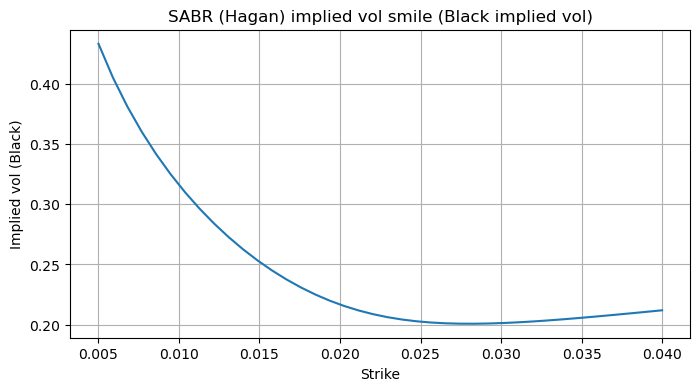

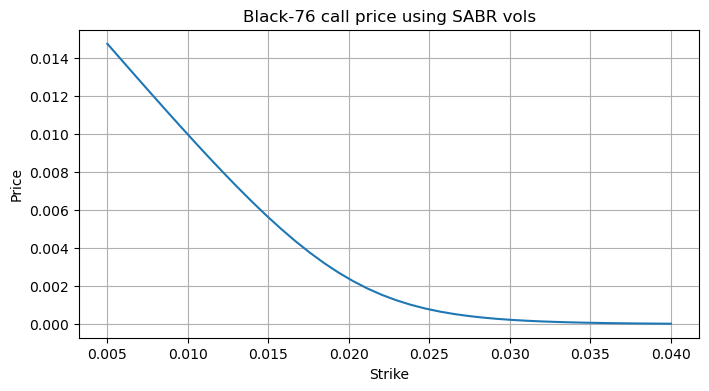

In [3]:
# SABR - Stochastic ALPHA BETA RHO 
# BSM-76 where underlying are forwards -> Swaptions, Foor
# BSM -> equities

import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def sabr_hagan_implied_vol(F, K, T, alpha, beta, rho, nu):
    if F <= 0 or K <= 0:
        raise ValueError("F and K must be positive for the lognormal SABR formula.")
    # ATM case
    if abs(F - K) < 1e-12:
        FK_beta = F**(1-beta)
        alpha_term = alpha / FK_beta
        term1 = ( (1-beta)**2 / 24.0 ) * (alpha**2) / (F**(2-2*beta))
        term2 = ( rho*beta*alpha*nu ) / (4.0 * F**(1-beta) )
        term3 = ( (2 - 3*rho**2) * nu**2 / 24.0 )
        vol_atm = alpha_term * (1 + (term1 + term2 + term3) * T)
        return vol_atm

    FK_beta = (F*K)**((1-beta)/2.0)
    logFK = math.log(F/K)
    one_minus_beta = 1 - beta

    z = (nu/alpha) * FK_beta * logFK
    denom = 1 - rho
    numer = math.sqrt(1 - 2*rho*z + z*z) + z - rho
    x_z = math.log(numer / denom)

    A = alpha / ( FK_beta * (1 + (one_minus_beta**2/24.0)*(logFK**2) + (one_minus_beta**4/1920.0)*(logFK**4)) )
    B = z / x_z

    term1 = ( (one_minus_beta**2) / 24.0 ) * (alpha**2) / ( (FK_beta**2) )
    term2 = ( rho*beta*alpha*nu ) / (4.0 * FK_beta )
    term3 = ( (2 - 3*rho**2) * (nu**2) / 24.0 )
    correction = 1 + (term1 + term2 + term3) * T

    implied_vol = A * B * correction
    return implied_vol

def black76_call_price(F, K, T, vol, df=1.0):
    if vol <= 0 or T <= 0:
        payoff = max(F - K, 0.0)
        return df * payoff
    sigma_sqrt_t = vol * math.sqrt(T)
    d1 = (math.log(F/K) + 0.5 * vol**2 * T) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    price = df * (F * norm_cdf(d1) - K * norm_cdf(d2))
    return price

def bsm_call_price(S, K, r, q, T, vol):
    if vol <= 0 or T <= 0:
        return math.exp(-r*T) * max(S*math.exp(-q*T) - K, 0.0)
    sigma_sqrt_t = vol * math.sqrt(T)
    d1 = (math.log(S/K) + (r - q + 0.5 * vol**2) * T) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    price = math.exp(-q*T) * S * norm_cdf(d1) - math.exp(-r*T) * K * norm_cdf(d2)
    return price

# !!! Example parameters
alpha = 0.03   # vol scale
beta = 0.5     # elasticity (0 normal -> 1 lognormal)
rho = -0.2     # corr between forward and vol
nu = 0.4       # vol-of-vol
F = 0.02     # forward (2%)
T = 2.0
r = 0.01
df = math.exp(-r*T)

# Build smile and prices
strikes = np.linspace(0.005, 0.04, 40)
implied_vols = np.array([sabr_hagan_implied_vol(F, K, T, alpha, beta, rho, nu) for K in strikes])
black_prices = np.array([black76_call_price(F, K, T, vol, df=df) for K, vol in zip(strikes, implied_vols)])

# Show a worked number
K_example = 0.025
vol_example = sabr_hagan_implied_vol(F, K_example, T, alpha, beta, rho, nu)
price_black = black76_call_price(F, K_example, T, vol_example, df=df)

print("Worked example:")
print(f"F={F:.4f}, K={K_example:.4f}, T={T}, DF={df:.6f}")
print(f"SABR params alpha={alpha}, beta={beta}, rho={rho}, nu={nu}")
print(f"SABR implied Black vol at K={K_example:.4f} -> {vol_example:.6f}")
print(f"Black-76 call price (discounted) -> {price_black:.8f}")

# Plot
plt.figure(figsize=(8,4))
plt.plot(strikes, implied_vols)
plt.title("SABR (Hagan) implied vol smile (Black implied vol)")
plt.xlabel("Strike")
plt.ylabel("Implied vol (Black)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(strikes, black_prices)
plt.title("Black-76 call price using SABR vols")
plt.xlabel("Strike")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [10]:
#SABR with normal BSM

import math
import numpy as np

# ----------------------------
# Normal cdf
# ----------------------------
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# ----------------------------
# SABR Hagan (Black implied vol) implementation (same as provided earlier)
# Inputs: F (forward), K (strike), T, alpha, beta, rho, nu
# Returns: Black implied vol (lognormal)
# ----------------------------
def sabr_hagan_implied_vol(F, K, T, alpha, beta, rho, nu):
    if F <= 0 or K <= 0:
        raise ValueError("F and K must be positive for the lognormal SABR formula.")
    if abs(F - K) < 1e-12:
        FK_beta = F**(1-beta)
        alpha_term = alpha / FK_beta
        term1 = ( (1-beta)**2 / 24.0 ) * (alpha**2) / (F**(2-2*beta))
        term2 = ( rho*beta*alpha*nu ) / (4.0 * F**(1-beta) )
        term3 = ( (2 - 3*rho**2) * nu**2 / 24.0 )
        vol_atm = alpha_term * (1 + (term1 + term2 + term3) * T)
        return vol_atm

    FK_beta = (F*K)**((1-beta)/2.0)
    logFK = math.log(F/K)
    one_minus_beta = 1 - beta

    z = (nu/alpha) * FK_beta * logFK
    denom = 1 - rho
    numer = math.sqrt(1 - 2*rho*z + z*z) + z - rho
    x_z = math.log(numer / denom)

    A = alpha / ( FK_beta * (1 + (one_minus_beta**2/24.0)*(logFK**2) + (one_minus_beta**4/1920.0)*(logFK**4)) )
    B = z / x_z

    term1 = ( (one_minus_beta**2) / 24.0 ) * (alpha**2) / ( (FK_beta**2) )
    term2 = ( rho*beta*alpha*nu ) / (4.0 * FK_beta )
    term3 = ( (2 - 3*rho**2) * (nu**2) / 24.0 )
    correction = 1 + (term1 + term2 + term3) * T

    implied_vol = A * B * correction
    return implied_vol

# ----------------------------
# Black-Scholes-Merton (BSM) call & put (spot) with continuous dividend q
# S = spot, K = strike, r = risk-free, q = continuous dividend yield, T, vol
# ----------------------------
def bsm_call_price(S, K, r, q, T, vol):
    if vol <= 0 or T <= 0:
        return math.exp(-r*T) * max(S*math.exp(-q*T) - K, 0.0)
    sigma_sqrt_t = vol * math.sqrt(T)
    d1 = (math.log(S/K) + (r - q + 0.5 * vol**2) * T) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    return math.exp(-q*T) * S * norm_cdf(d1) - math.exp(-r*T) * K * norm_cdf(d2)

def bsm_put_price_from_c(S, K, r, q, T, call_price):
    # put-call parity
    return call_price + K * math.exp(-r*T) - S * math.exp(-q*T)

# ----------------------------
# Example: use SABR to create an implied vol smile for a stock (use BSM for prices)
# ----------------------------
S = 100.0           # spot price
r = 0.02            # risk-free 2%
q = 0.00            # dividend yield (0 if none)
T = 1.0             # 1 year to maturity

# SABR parameters (example)
alpha = 0.25        # vol scale (choose so ATM vol reasonable)
beta = 0.5
rho = -0.2
nu = 0.6

# compute forward from spot
F = S * math.exp((r - q) * T)

# Make strikes: include ITM and OTM calls and puts
strikes = np.array([60, 64.2, 68.4, 72.6, 76.8, 81.1, 90, 100, 110, 120])  # example
print(f"Spot S={S:.2f}, Forward F={F:.4f}, r={r}, q={q}, T={T}\n")

print("K | SABR_vol | BSM_call (long) | BSM_put (via parity) |  short call | short put")
for K in strikes:
    # compute SABR vol on forward scale (use K expressed in same units as F)
    vol_black = sabr_hagan_implied_vol(F, K, T, alpha, beta, rho, nu)
    # same numeric vol can be used as BSM vol for spot if we've built F consistently
    call_price = bsm_call_price(S, K, r, q, T, vol_black)
    put_price = bsm_put_price_from_c(S, K, r, q, T, call_price)
    print(f"{K:5.1f} | {vol_black:7.4f} | {call_price:14.4f} | {put_price:18.4f} | { -call_price:10.4f} | { -put_price:9.4f}")

Spot S=100.00, Forward F=102.0201, r=0.02, q=0.0, T=1.0

K | SABR_vol | BSM_call (long) | BSM_put (via parity) |  short call | short put
 60.0 |  0.1106 |        41.1881 |             0.0000 |   -41.1881 |   -0.0000
 64.2 |  0.1005 |        37.0712 |             0.0000 |   -37.0712 |   -0.0000
 68.4 |  0.0909 |        32.9544 |             0.0000 |   -32.9544 |   -0.0000
 72.6 |  0.0817 |        28.8376 |             0.0000 |   -28.8376 |   -0.0000
 76.8 |  0.0727 |        24.7208 |             0.0001 |   -24.7208 |   -0.0001
 81.1 |  0.0639 |        20.5061 |             0.0002 |   -20.5061 |   -0.0002
 90.0 |  0.0460 |        11.7863 |             0.0042 |   -11.7863 |   -0.0042
100.0 |  0.0276 |         2.3542 |             0.3741 |    -2.3542 |   -0.3741
110.0 |  0.0309 |         0.0079 |             7.8297 |    -0.0079 |   -7.8297
120.0 |  0.0437 |         0.0001 |            17.6240 |    -0.0001 |  -17.6240
